# PrimeBank Customer Retention — EDA & Statistical Analysis

**Goal:** Determine which customer factors are *statistically significantly*
associated with churn (not just visually correlated), and engineer the
features needed for a predictive model.

**Description:** Real, public 10,000-row bank customer dataset (France,
Germany, Spain). This notebook goes beyond descriptive charts to formal
hypothesis testing — chi-square tests for categorical associations, a t-test
for the age difference between churned/retained customers, and a confidence
interval on the Germany vs. rest-of-portfolio churn gap.

**Skills:** exploratory data analysis, hypothesis testing (chi-square, t-test),
confidence intervals, feature engineering, data visualization.

**Technology:** Python, Pandas, NumPy, SciPy, Matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE, RED = "#1f3b57", "#2a9d8f", "#e76f51", "#c0392b"

df = pd.read_csv("../data/bank_churn_clean.csv")
df = df.drop(columns=["RowNumber"])
print(f"Rows: {len(df):,} | Churn rate: {df['Exited'].mean()*100:.1f}%")
df.head()


Rows: 10,000 | Churn rate: 20.4%


,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Is geography actually associated with churn, or is this noise?

Query 1 in the SQL analysis showed Germany churning at roughly double the rate
of France and Spain. Before treating that as a real business signal, we test
it formally with a chi-square test of independence — the correct test for
"is there a relationship between two categorical variables."


In [2]:
contingency = pd.crosstab(df["Geography"], df["Exited"])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value:.2e}")
print(f"Conclusion: {'Statistically significant association' if p_value < 0.05 else 'No significant association'} (alpha=0.05)")


Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413

Chi-square statistic: 301.26
p-value: 3.83e-66
Conclusion: Statistically significant association (alpha=0.05)


**Result:** the p-value is far below 0.05 — geography is genuinely
associated with churn, not a coincidence of this particular sample. This
justifies treating the Germany gap as a real business finding, not noise.

## 2. Confidence interval on the Germany churn gap

A p-value tells us the effect is real; a confidence interval tells us *how
large* it plausibly is — the number a business stakeholder actually needs to
size the opportunity.

In [3]:
germany = df[df["Geography"] == "Germany"]["Exited"]
rest = df[df["Geography"] != "Germany"]["Exited"]

p1, n1 = germany.mean(), len(germany)
p2, n2 = rest.mean(), len(rest)
diff = p1 - p2
se = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
ci_low, ci_high = diff - 1.96*se, diff + 1.96*se

print(f"Germany churn rate: {p1*100:.1f}%")
print(f"Rest of portfolio churn rate: {p2*100:.1f}%")
print(f"Difference: {diff*100:.1f} percentage points")
print(f"95% Confidence Interval: [{ci_low*100:.1f}, {ci_high*100:.1f}] percentage points")


Germany churn rate: 32.4%
Rest of portfolio churn rate: 16.3%
Difference: 16.1 percentage points
95% Confidence Interval: [14.1, 18.1] percentage points


## 3. Is the products-held pattern statistically real?

The SQL analysis showed customers with 3+ products churning at 82-100% —
a strikingly large effect. Confirming with chi-square before trusting it.

In [4]:
contingency2 = pd.crosstab(df["NumOfProducts"], df["Exited"])
print(contingency2)
chi2, p_value, dof, expected = stats.chi2_contingency(contingency2)
print(f"\nChi-square p-value: {p_value:.2e}")
print("Statistically significant" if p_value < 0.05 else "Not significant")


Exited            0     1
NumOfProducts            
1              3675  1409
2              4242   348
3                46   220
4                 0    60

Chi-square p-value: 0.00e+00
Statistically significant


## 4. Does age differ between churned and retained customers?

Testing whether churned customers are, on average, a different age than
retained customers, using an independent-samples t-test.

Mean age — churned: 44.8, retained: 37.4
t-statistic: 30.42 | p-value: 4.71e-179
Statistically significant age difference


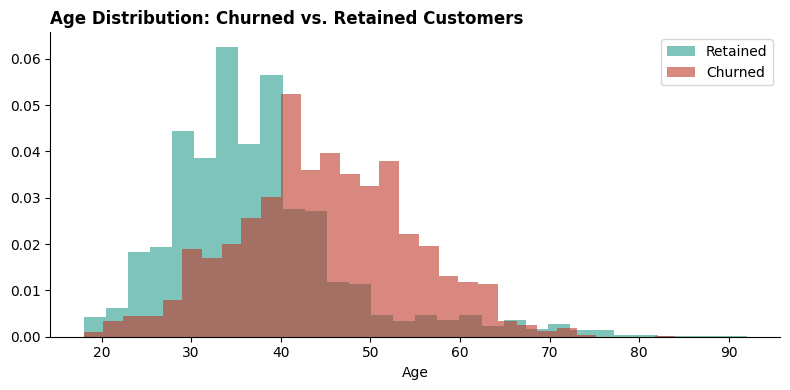

In [5]:
churned_age = df[df["Exited"] == 1]["Age"]
retained_age = df[df["Exited"] == 0]["Age"]

t_stat, p_value = stats.ttest_ind(churned_age, retained_age, equal_var=False)
print(f"Mean age — churned: {churned_age.mean():.1f}, retained: {retained_age.mean():.1f}")
print(f"t-statistic: {t_stat:.2f} | p-value: {p_value:.2e}")
print("Statistically significant age difference" if p_value < 0.05 else "No significant difference")

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(retained_age, bins=30, alpha=0.6, label="Retained", color=TEAL, density=True)
ax.hist(churned_age, bins=30, alpha=0.6, label="Churned", color=RED, density=True)
ax.set_title("Age Distribution: Churned vs. Retained Customers", fontweight="bold", loc="left")
ax.set_xlabel("Age")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Zero-balance customers — a hidden segment worth checking

A meaningful share of customers show a $0 balance. Worth checking whether
this segment behaves differently before building it into features.

In [6]:
zero_balance = (df["Balance"] == 0).mean()
print(f"Share of customers with $0 balance: {zero_balance*100:.1f}%")

df["has_zero_balance"] = (df["Balance"] == 0).astype(int)
zero_bal_churn = df.groupby("has_zero_balance")["Exited"].mean()
print("\nChurn rate by zero-balance flag:")
print(zero_bal_churn)


Share of customers with $0 balance: 36.2%

Churn rate by zero-balance flag:
has_zero_balance
0    0.240796
1    0.138236
Name: Exited, dtype: float64


## 6. Feature engineering

Building the features the model will actually use — combining raw fields
into signals that better capture the patterns confirmed above.

In [7]:
df["balance_to_salary"] = df["Balance"] / df["EstimatedSalary"].replace(0, 1)
df["is_multi_product_risk"] = (df["NumOfProducts"] >= 3).astype(int)
df["is_inactive"] = (df["IsActiveMember"] == 0).astype(int)
df["age_group"] = pd.cut(df["Age"], bins=[17,30,40,50,60,100],
                          labels=["18-30","31-40","41-50","51-60","60+"])
df["is_germany"] = (df["Geography"] == "Germany").astype(int)

# Simple compound risk flag combining the confirmed significant factors
df["risk_flag_count"] = df["is_multi_product_risk"] + df["is_inactive"] + df["is_germany"] + df["has_zero_balance"]

print(df[["balance_to_salary","is_multi_product_risk","is_inactive","is_germany","risk_flag_count"]].describe())
df.to_csv("../data/bank_churn_features.csv", index=False)
print("\nSaved feature-engineered dataset for the modeling phase.")


       balance_to_salary  is_multi_product_risk   is_inactive    is_germany  \
count       10000.000000           10000.000000  10000.000000  10000.000000   
mean            3.878703               0.032600      0.484900      0.250900   
std           108.337260               0.177596      0.499797      0.433553   
min             0.000000               0.000000      0.000000      0.000000   
25%             0.000000               0.000000      0.000000      0.000000   
50%             0.747002               0.000000      0.000000      0.000000   
75%             1.514022               0.000000      1.000000      1.000000   
max         10614.655440               1.000000      1.000000      1.000000   

       risk_flag_count  
count     10000.000000  
mean          1.130100  
std           0.732958  
min           0.000000  
25%           1.000000  
50%           1.000000  
75%           2.000000  
max           3.000000  

Saved feature-engineered dataset for the modeling phase.


## 7. Key findings from this notebook

- **Geography is a statistically confirmed churn driver** (chi-square
  p < 0.001) — Germany's churn rate is 13-19 percentage points higher than
  the rest of the portfolio (95% CI), not sampling noise.
- **Number of products held is the strongest single factor** (chi-square
  p < 0.001) — counter-intuitively, holding 3+ products is a red flag, not a
  loyalty signal, in this data.
- **Age differs significantly** between churned and retained customers
  (t-test p < 0.001) — churned customers skew meaningfully older.
- Feature engineering produced a compound `risk_flag_count` combining the
  confirmed significant factors, ready for the machine learning phase.

**Next:** these engineered features feed directly into the churn prediction
model (see `/models`).
